In [ ]:
# Mall Customer Segmentation using K-Means Clustering


In [36]:
import pandas as pd
df=pd.read_csv(r"C:\Users\onc\Downloads\mall_customers.csv")
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Email,Phone
0,1,Male,19,15,39,customer1@mall.com,+1-555-1000
1,2,Male,21,15,81,customer2@mall.com,+1-555-1001
2,3,Female,20,16,6,customer3@mall.com,+1-555-1002
3,4,Female,23,16,77,customer4@mall.com,+1-555-1003
4,5,Female,31,17,40,customer5@mall.com,+1-555-1004
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,customer196@mall.com,+1-555-1195
196,197,Female,45,126,28,customer197@mall.com,+1-555-1196
197,198,Male,32,126,74,customer198@mall.com,+1-555-1197
198,199,Male,32,137,18,customer199@mall.com,+1-555-1198


In [37]:
df.shape

(200, 7)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
 5   Email                   200 non-null    object
 6   Phone                   200 non-null    object
dtypes: int64(4), object(3)
memory usage: 11.1+ KB


In [39]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [40]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Email                     0
Phone                     0
dtype: int64

In [41]:
df = df.rename(columns={
    'Genre': 'Gender',
    'Annual Income (k$)': 'Income',
    'Spending Score (1-100)': 'SpendingScore'
})
df = df.drop(columns=['CustomerID'])
df.head()

,Gender,Age,Income,SpendingScore,Email,Phone
0,Male,19,15,39,customer1@mall.com,+1-555-1000
1,Male,21,15,81,customer2@mall.com,+1-555-1001
2,Female,20,16,6,customer3@mall.com,+1-555-1002
3,Female,23,16,77,customer4@mall.com,+1-555-1003
4,Female,31,17,40,customer5@mall.com,+1-555-1004


In [42]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


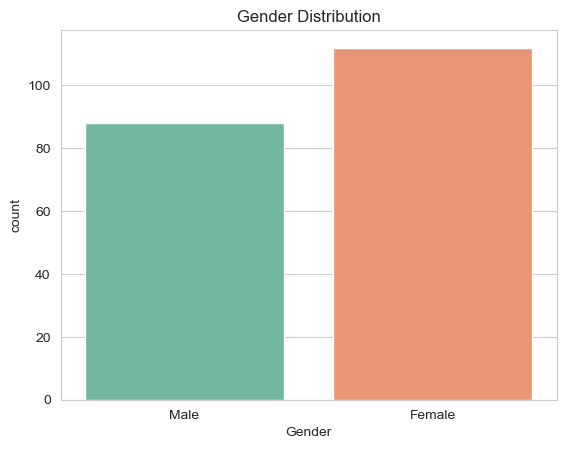

In [43]:
# EDA (Exploratory Data Analysis)

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

sns.countplot(data=df, x='Gender', palette='Set2', hue='Gender', legend=False)
plt.title('Gender Distribution')
plt.show()

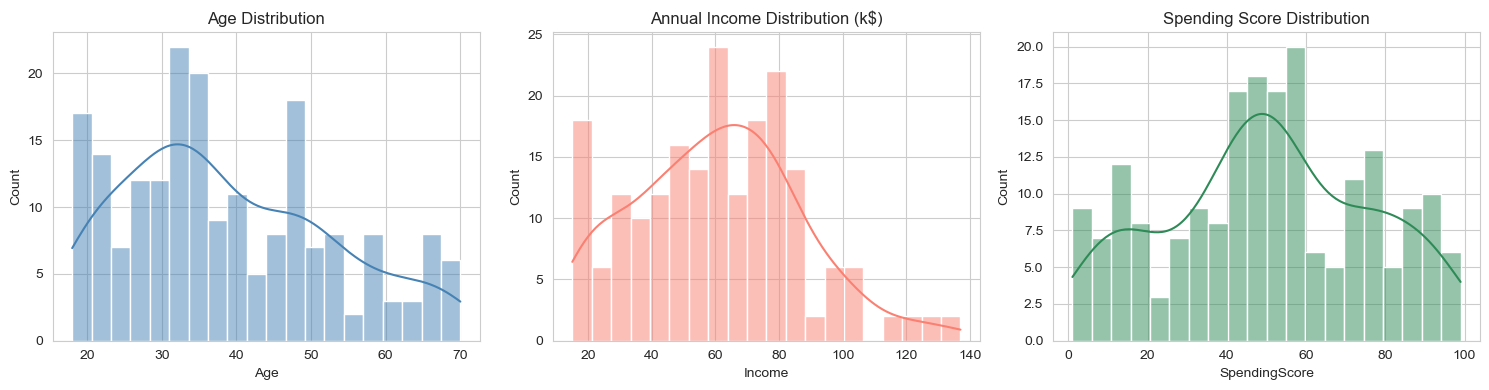

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['Age'], kde=True, bins=20, color='steelblue', ax=axes[0])
axes[0].set_title('Age Distribution')

sns.histplot(df['Income'], kde=True, bins=20, color='salmon', ax=axes[1])
axes[1].set_title('Annual Income Distribution (k$)')

sns.histplot(df['SpendingScore'], kde=True, bins=20, color='seagreen', ax=axes[2])
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()

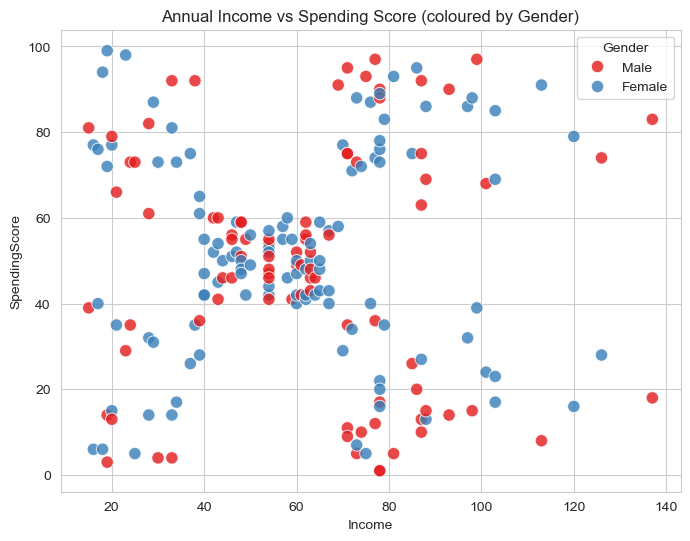

In [45]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Income', y='SpendingScore',
                hue='Gender', s=80, alpha=0.8, palette='Set1')
plt.title('Annual Income vs Spending Score (coloured by Gender)')
plt.show()

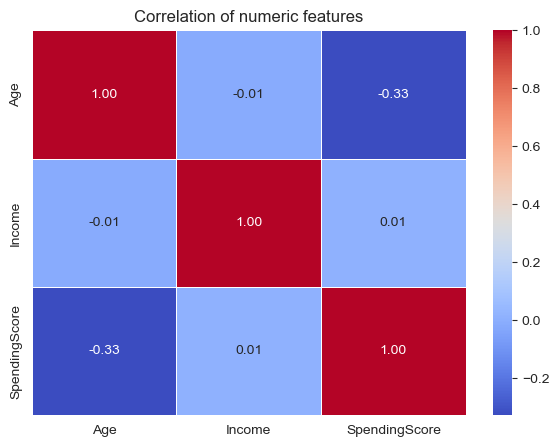

In [46]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[['Age','Income','SpendingScore']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.4)
plt.title('Correlation of numeric features')
plt.show()

In [47]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df.head()

,Gender,Age,Income,SpendingScore,Email,Phone
0,0,19,15,39,customer1@mall.com,+1-555-1000
1,0,21,15,81,customer2@mall.com,+1-555-1001
2,1,20,16,6,customer3@mall.com,+1-555-1002
3,1,23,16,77,customer4@mall.com,+1-555-1003
4,1,31,17,40,customer5@mall.com,+1-555-1004


In [48]:
X = df[['Gender', 'Age', 'Income', 'SpendingScore']].copy()
print('Feature matrix shape:', X.shape)
X.head()

Feature matrix shape: (200, 4)


,Gender,Age,Income,SpendingScore
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [50]:
# Feature scaling with StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\onc\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\onc\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\onc\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\onc\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^


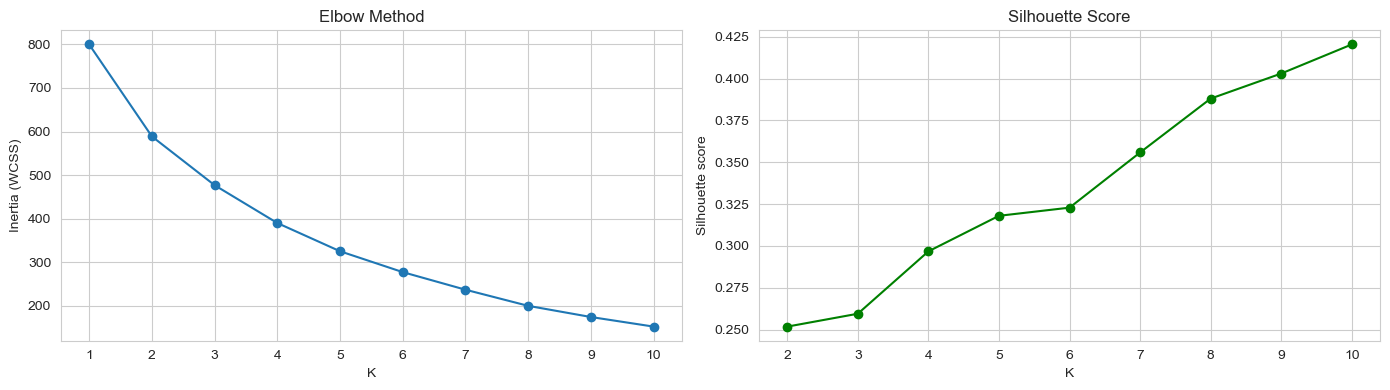

Best K by silhouette = 10  (score = 0.4203)


In [51]:
# Choose the number of clusters K

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
k_values = range(1, 11)
k_values_s = range(2, 11)   # silhouette needs at least 2 clusters

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=1)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    if k >= 2:
        sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(k_values, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_xticks(list(k_values))

axes[1].plot(k_values_s, sil_scores, marker='o', color='green')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette score')
axes[1].set_xticks(list(k_values_s))

plt.tight_layout()
plt.show()

best_k = k_values_s[sil_scores.index(max(sil_scores))]
print(f'Best K by silhouette = {best_k}  (score = {max(sil_scores):.4f})')

In [52]:
# Train the final K-Means model

final_k = 6

kmeans = KMeans(n_clusters=final_k, n_init=10, random_state=1)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print('Customers per cluster:')
print(df['Cluster'].value_counts().sort_index())

C:\Users\onc\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Customers per cluster:
Cluster
0    23
1    39
2    36
3    48
4    27
5    27
Name: count, dtype: int64


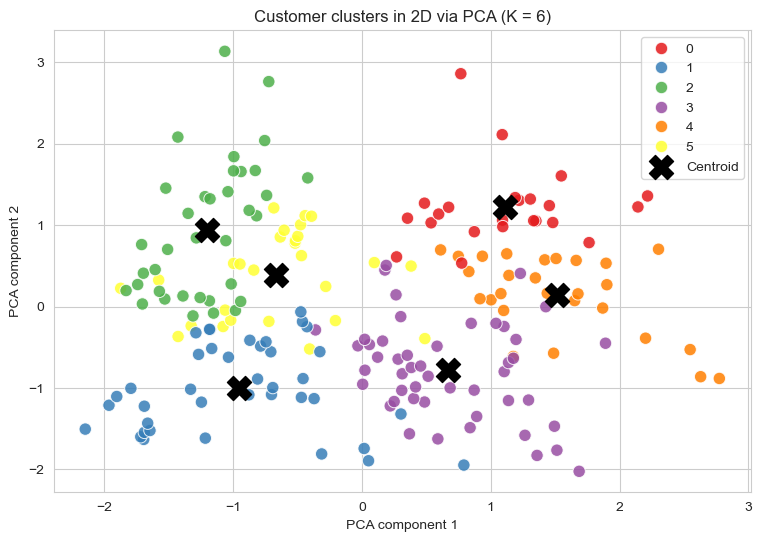

Variance explained by 2 PCA components: 0.599


In [53]:
# Visualize the clusters

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=1)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=df['Cluster'], palette='Set1', s=80, alpha=0.85)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            marker='X', s=300, c='black', label='Centroid')
plt.title(f'Customer clusters in 2D via PCA (K = {final_k})')
plt.xlabel('PCA component 1')
plt.ylabel('PCA component 2')
plt.legend()
plt.show()

print('Variance explained by 2 PCA components:',
      round(pca.explained_variance_ratio_.sum(), 3))

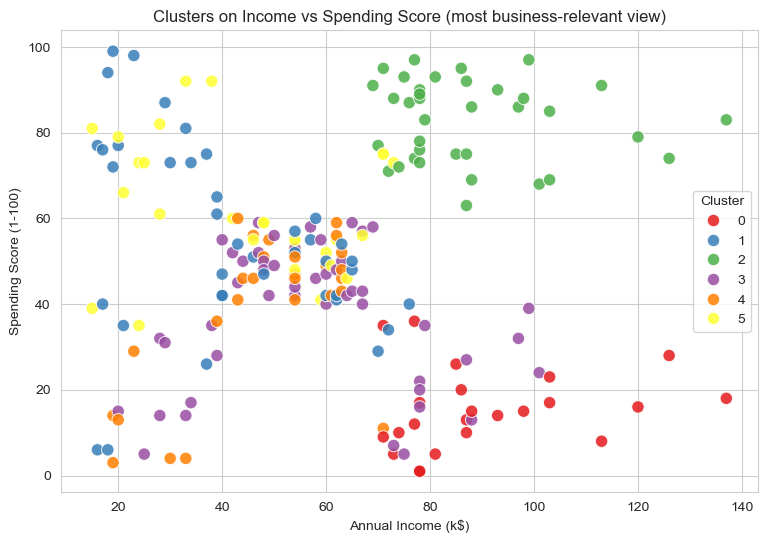

In [54]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Income', y='SpendingScore',
                hue='Cluster', palette='Set1', s=80, alpha=0.85)
plt.title('Clusters on Income vs Spending Score (most business-relevant view)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [ ]:
# Cluster profile — read each cluster's fingerprint

# For each cluster we look at:

# Customers — how big the segment is
# Avg_Age — typical age
# Avg_Income — typical income (k$)
# Avg_Spending — typical spending score
# Pct_Female — gender skew (%)
# This table is the single most important output for marketing — it's the persona fingerprint of each cluster.

In [55]:
profile = df.groupby('Cluster').agg(
    Customers=('Age', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Income', 'mean'),
    Avg_Spending=('SpendingScore', 'mean'),
    Pct_Female=('Gender', lambda s: round(s.mean()*100, 1))
).round(1)

# Sort clusters by income then spending for easier reading
profile = profile.sort_values(['Avg_Income', 'Avg_Spending'])
profile

,Customers,Avg_Age,Avg_Income,Avg_Spending,Pct_Female
Cluster,,,,,
1,39,26.4,41.5,55.3,100.0
5,27,26.5,44.6,62.4,0.0
4,27,58.0,47.6,38.9,0.0
3,48,49.9,57.5,37.8,100.0
2,36,32.4,87.8,82.8,58.3
0,23,39.0,90.6,15.4,17.4


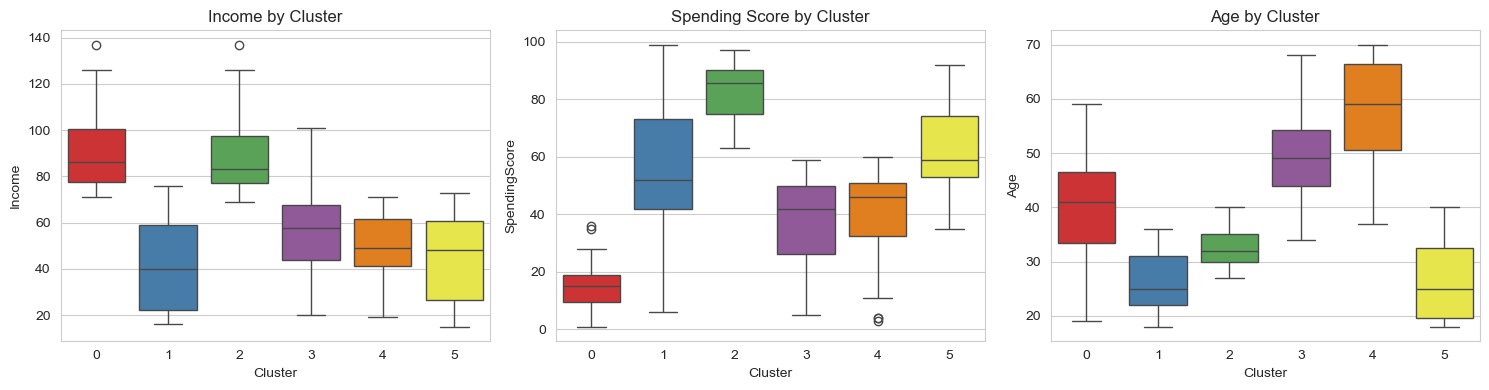

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, x='Cluster', y='Income', hue='Cluster',
            palette='Set1', ax=axes[0], legend=False)
axes[0].set_title('Income by Cluster')

sns.boxplot(data=df, x='Cluster', y='SpendingScore', hue='Cluster',
            palette='Set1', ax=axes[1], legend=False)
axes[1].set_title('Spending Score by Cluster')

sns.boxplot(data=df, x='Cluster', y='Age', hue='Cluster',
            palette='Set1', ax=axes[2], legend=False)
axes[2].set_title('Age by Cluster')

plt.tight_layout()
plt.show()

In [ ]:
# 0 -> Wealthy Conservative 1 -> Budget Shoppers 2 -> Premium Loyalists 3 -> Average Customers 4 -> Senior Customers 5 -> Young High Spenders

In [ ]:
# From Clusters to Real-World Marketing Campaigns
# Right now the mall sends the same email to everyone — and very few people open it.

# After clustering, we have 6 different groups of customers. Each group is different, so we should send each group a different message.

# We do this in 3 simple steps:

# Give each group a simple name.
# Decide a simple campaign for each group — what offer + which channel.
# Put it all into a summary table the marketing team can use.

In [57]:
# First look at each cluster's average values so we know who they are
profile = df.groupby('Cluster')[['Age', 'Income', 'SpendingScore']].mean().round(1)
print(profile)

# Now give each cluster a simple name
persona_map = {
    0: 'Wealthy Conservative',
    1: 'Budget Shoppers',
    2: 'Premium Loyalists',
    3: 'Average Customers',
    4: 'Senior Customers',
    5: 'Young High Spenders'
}

df['Persona'] = df['Cluster'].map(persona_map)
df.head()

          Age  Income  SpendingScore
Cluster                             
0        39.0    90.6           15.4
1        26.4    41.5           55.3
2        32.4    87.8           82.8
3        49.9    57.5           37.8
4        58.0    47.6           38.9
5        26.5    44.6           62.4


,Gender,Age,Income,SpendingScore,Email,Phone,Cluster,Persona
0,0,19,15,39,customer1@mall.com,+1-555-1000,5,Young High Spenders
1,0,21,15,81,customer2@mall.com,+1-555-1001,5,Young High Spenders
2,1,20,16,6,customer3@mall.com,+1-555-1002,1,Budget Shoppers
3,1,23,16,77,customer4@mall.com,+1-555-1003,1,Budget Shoppers
4,1,31,17,40,customer5@mall.com,+1-555-1004,1,Budget Shoppers


In [58]:
# Simple summary table - one row per group
campaigns = pd.DataFrame({
    'Persona': ['Wealthy Conservative', 'Budget Shoppers', 'Premium Loyalists',
                'Average Customers',    'Senior Customers', 'Young High Spenders'],
    'Offer':   ['Loyalty points + family bundles',
                'Big discounts + Buy 1 Get 1 free',
                'VIP previews + personal shopper',
                'Seasonal sales + new launches',
                'Senior discount + free coffee',
                'Trendy drops + Buy Now Pay Later'],
    'Channel': ['Email + Facebook',
                'SMS + Email',
                'Phone call + WhatsApp',
                'Email + Mobile App',
                'SMS + Printed flyers',
                'Instagram + TikTok']
})
campaigns

,Persona,Offer,Channel
0,Wealthy Conservative,Loyalty points + family bundles,Email + Facebook
1,Budget Shoppers,Big discounts + Buy 1 Get 1 free,SMS + Email
2,Premium Loyalists,VIP previews + personal shopper,Phone call + WhatsApp
3,Average Customers,Seasonal sales + new launches,Email + Mobile App
4,Senior Customers,Senior discount + free coffee,SMS + Printed flyers
5,Young High Spenders,Trendy drops + Buy Now Pay Later,Instagram + TikTok


In [59]:
# Add Offer and Channel columns into the main customer DataFrame
df = df.merge(campaigns, on='Persona', how='left')
df.head()

,Gender,Age,Income,SpendingScore,Email,Phone,Cluster,Persona,Offer,Channel
0,0,19,15,39,customer1@mall.com,+1-555-1000,5,Young High Spenders,Trendy drops + Buy Now Pay Later,Instagram + TikTok
1,0,21,15,81,customer2@mall.com,+1-555-1001,5,Young High Spenders,Trendy drops + Buy Now Pay Later,Instagram + TikTok
2,1,20,16,6,customer3@mall.com,+1-555-1002,1,Budget Shoppers,Big discounts + Buy 1 Get 1 free,SMS + Email
3,1,23,16,77,customer4@mall.com,+1-555-1003,1,Budget Shoppers,Big discounts + Buy 1 Get 1 free,SMS + Email
4,1,31,17,40,customer5@mall.com,+1-555-1004,1,Budget Shoppers,Big discounts + Buy 1 Get 1 free,SMS + Email


In [1]:
# Save the final table for the marketing team
# out_path = r'"C:\Users\onc\Downloads\mall_customers.csv'
# df.to_csv(out_path, index=False)
# print('Saved', out_path, 'with', len(df), 'customers x', len(df.columns), 'columns.')